## Experiments stats

### Setup

In [1]:
import os
from pathlib import Path
import pickle
import json
import warnings
import logging

import pandas as pd
import numpy as np

In [2]:
warnings.filterwarnings("ignore", category=SyntaxWarning)

from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Turn off pgmpy info messages
logging.getLogger('pgmpy').setLevel(logging.WARNING)

# Or turn off all info messages
logging.basicConfig(level=logging.WARNING)

In [3]:
project_path = Path(Path.cwd()).parent.parent

In [4]:
SEED = 7777

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import shapiro, levene
import pingouin as pg


def run_factorial_anova(df, id_vars, value_vars, metric, output_dir, ols_expr=None):
    """
    Ejecuta un ANOVA factorial verificando supuestos de normalidad y homogeneidad,
    y guarda todos los resultados en archivos Excel sin índice.
    """

    os.makedirs(output_dir, exist_ok=True)

    # ============================================================== #
    # || 1. Reestructurar el DataFrame                              ||
    # ============================================================== #
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=value_vars,
        var_name="iteration",
        value_name=metric
    )

    # ============================================================== #
    # || 2. Ajustar modelo OLS y obtener residuos                   ||
    # ============================================================== #
    if ols_expr is None:
        # Build expression dynamically from all categorical factors
        factors = " * ".join([f"C({col})" for col in id_vars])
        ols_expr = f"{metric} ~ {factors}"

    model = ols(ols_expr, data=df_long).fit()
    residuals = model.resid

    # Test de normalidad de residuos
    stat_res, p_res = shapiro(residuals)
    print(f"\nResiduos: W={stat_res:.4f}, p={p_res:.4f}")

    # QQ plot
    qqplot_path = os.path.join(output_dir, f"qqplot_{metric}.png")
    sm.qqplot(residuals, line="45", fit=True)
    plt.title(f"QQ Plot de residuos ({metric})")
    plt.savefig(qqplot_path, bbox_inches="tight")
    plt.close()

    # ============================================================== #
    # || 3. Normalidad por grupo                                    ||
    # ============================================================== #
    normality_results = []
    for name, group in df_long.groupby(id_vars):
        if len(group) >= 3:
            stat, p = shapiro(group[metric])
            record = {col: val for col, val in zip(id_vars, name)}
            record.update({"n": len(group), "W": stat, "p": p})
            normality_results.append(record)

    df_normality = pd.DataFrame(normality_results)
    normality_path = os.path.join(output_dir, f"normality_{metric}.xlsx")
    df_normality.to_excel(normality_path, index=False)
    print(f"Normalidad por grupo guardada en: {normality_path}")

    # ============================================================== #
    # || 4. Homogeneidad de varianzas (Levene)                      ||
    # ============================================================== #
    stat_lev, p_lev = levene(
        *[group[metric].values for _, group in df_long.groupby(id_vars)]
    )
    df_levene = pd.DataFrame([{"W": stat_lev, "p": p_lev}])
    levene_path = os.path.join(output_dir, f"levene_{metric}.xlsx")
    df_levene.to_excel(levene_path, index=False)
    print(f"Levene: W={stat_lev:.4f}, p={p_lev:.4f}")
    print(f"Resultados de Levene guardados en: {levene_path}")

    # ============================================================== #
    # || 5. ANOVA factorial (Pingouin)                              ||
    # ============================================================== #
    aov = pg.anova(
        dv=metric,
        between=id_vars,  # Use all factors provided
        data=df_long,
        detailed=True
    )

    # Rename columns to Spanish
    aov.rename(columns={
        "Source": "Fuente de variación",
        "SS": "Suma de cuadrados (SC)",
        "DF": "Grados de libertad (gl)",
        "MS": "Media de cuadrados (MC)",
        "F": "Estadístico F",
        "p-unc": "Valor p",
        "np2": "Eta cuadrado parcial (η²ₚ)"
    }, inplace=True)

    anova_path = os.path.join(output_dir, f"anova_factorial_{metric}.xlsx")
    aov.to_excel(anova_path, index=False)
    print(f"ANOVA factorial guardado en: {anova_path}")

    # ============================================================== #
    # || 6. Retornar resumen                                        ||
    # ============================================================== #
    return {
        "df_long": df_long,
        "model": model,
        "residuals": residuals,
        "shapiro_residuals": (stat_res, p_res),
        "normality_by_group": df_normality,
        "levene": (stat_lev, p_lev),
        "anova_table": aov
    }


### Naive Bayes

In [6]:
input_path = project_path / "data/outputs/naive_bayes.xlsx"
output_path = project_path / "data/outputs/naive_bayes"

In [7]:
df = pd.read_excel(input_path)

In [8]:
accuracy_cols = [f"accuracy_iter_{i}" for i in range(1, 26)]

results = run_factorial_anova(
    df=df,
    id_vars=["discretization_method", "input_config", "n_bins"],
    value_vars=accuracy_cols,
    metric="accuracy",
    output_dir=output_path.as_posix()
)


Residuos: W=0.9937, p=0.0363
Normalidad por grupo guardada en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/naive_bayes\normality_accuracy.xlsx
Levene: W=0.2492, p=0.9996
Resultados de Levene guardados en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/naive_bayes\levene_accuracy.xlsx
ANOVA factorial guardado en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/naive_bayes\anova_factorial_accuracy.xlsx


In [16]:
df_long = df.melt(
    id_vars=["input_config", "discretization_method", "n_bins"],
    value_vars=[f"auroc_iter_{i}" for i in range(1, 26)],
    var_name="iteration",
    value_name="auroc"
)

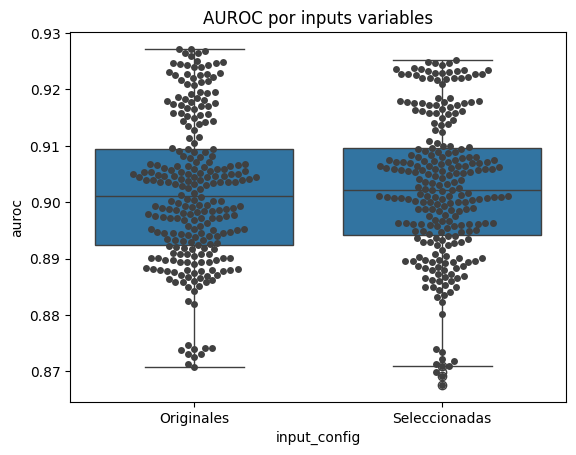

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="input_config", y="auroc", data=df_long)
sns.swarmplot(x="input_config", y="auroc", data=df_long, color=".25")
plt.title("AUROC por inputs variables")
plt.show()

### TAN

In [6]:
input_path = project_path / "data/outputs/tan.xlsx"
output_path = project_path / "data/outputs/tan"

In [7]:
df = pd.read_excel(input_path)

In [8]:
accuracy_cols = [f"accuracy_iter_{i}" for i in range(1, 26)]

results = run_factorial_anova(
    df=df,
    id_vars=["discretization_method", "input_config", "n_bins"],
    value_vars=accuracy_cols,
    metric="accuracy",
    output_dir=output_path.as_posix()
)


Residuos: W=0.9779, p=0.0000
Normalidad por grupo guardada en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/tan\normality_accuracy.xlsx
Levene: W=0.8251, p=0.6773
Resultados de Levene guardados en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/tan\levene_accuracy.xlsx
ANOVA factorial guardado en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/tan\anova_factorial_accuracy.xlsx


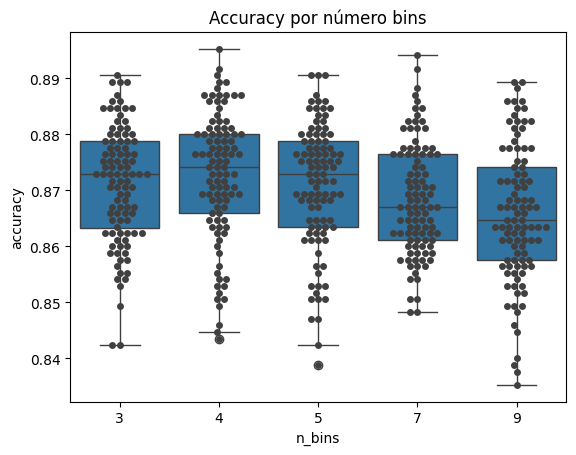

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df_long = df.melt(
    id_vars=["input_config", "discretization_method", "n_bins"],
    value_vars=[f"accuracy_iter_{i}" for i in range(1, 26)],
    var_name="iteration",
    value_name="accuracy"
)

sns.boxplot(x="n_bins", y="accuracy", data=df_long)
sns.swarmplot(x="n_bins", y="accuracy", data=df_long, color=".25")
plt.title("Accuracy por número bins")
plt.show()

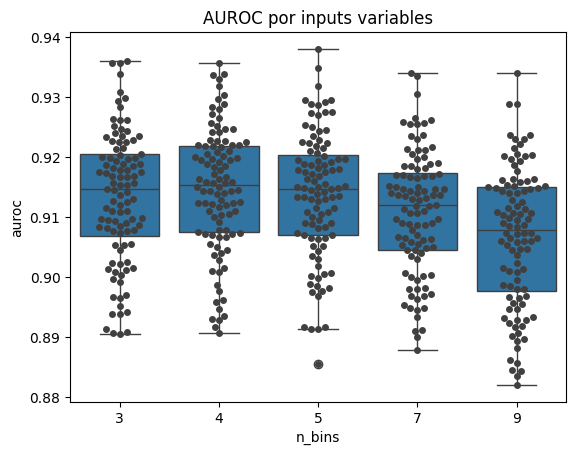

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df_long = df.melt(
    id_vars=["input_config", "discretization_method", "n_bins"],
    value_vars=[f"auroc_iter_{i}" for i in range(1, 26)],
    var_name="iteration",
    value_name="auroc"
)

sns.boxplot(x="n_bins", y="auroc", data=df_long)
sns.swarmplot(x="n_bins", y="auroc", data=df_long, color=".25")
plt.title("AUROC por inputs variables")
plt.show()

### Red Bayesiana

In [6]:
input_path = project_path / "data/outputs/bayesian_network.xlsx"
output_path = project_path / "data/outputs/bayesian_network"

In [7]:
df = pd.read_excel(input_path)

In [8]:
accuracy_cols = [f"accuracy_iter_{i}" for i in range(1, 26)]

results = run_factorial_anova(
    df=df,
    id_vars=["discretization_method", "input_config", "n_bins", "structure_method"],
    value_vars=accuracy_cols,
    metric="accuracy",
    output_dir=output_path.as_posix(),
)


Residuos: W=0.9898, p=0.0000
Normalidad por grupo guardada en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/bayesian_network\normality_accuracy.xlsx
Levene: W=0.6888, p=0.9653
Resultados de Levene guardados en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/bayesian_network\levene_accuracy.xlsx
ANOVA factorial guardado en: c:/Users/jrafa/Desktop/12-sistemas-inteligentes/curso-si-puj/data/outputs/bayesian_network\anova_factorial_accuracy.xlsx


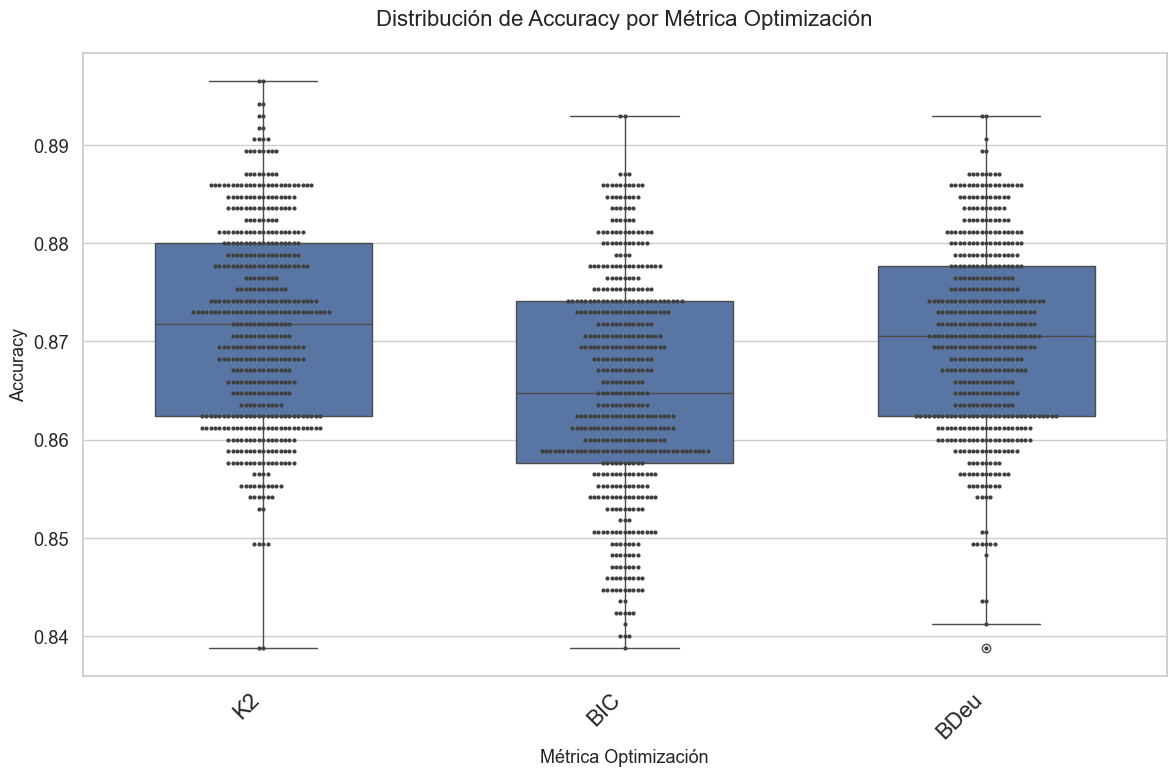

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reestructurar DataFrame
df_long = df.melt(
    id_vars=["input_config", "discretization_method", "n_bins", "structure_method"],
    value_vars=[f"accuracy_iter_{i}" for i in range(1, 26)],
    var_name="iteration",
    value_name="accuracy"
)

# Estilo más limpio y figura más alta
plt.figure(figsize=(12, 8))  # <-- controla el tamaño (ancho, alto)
sns.set(style="whitegrid", font_scale=1.2)

# Boxplot + Swarmplot superpuestos
ax = sns.boxplot(x="structure_method", y="accuracy", data=df_long, width=0.6)
sns.swarmplot(x="structure_method", y="accuracy", data=df_long, color=".25", size=3)

# Ajustes visuales
plt.title("Distribución de Accuracy por Métrica Optimización", fontsize=16, pad=20)
plt.xlabel("Métrica Optimización", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=16)

# Márgenes para evitar solapamiento
plt.tight_layout()
plt.show()

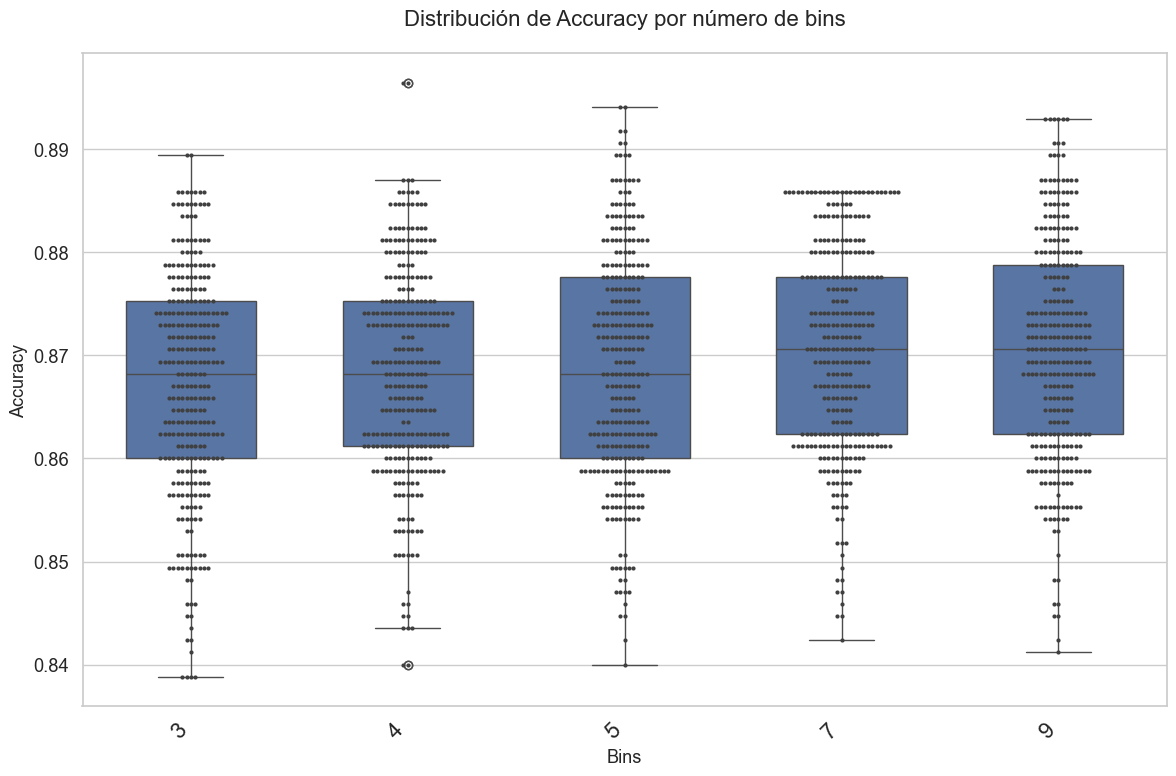

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reestructurar DataFrame
df_long = df.melt(
    id_vars=["input_config", "discretization_method", "n_bins", "structure_method"],
    value_vars=[f"accuracy_iter_{i}" for i in range(1, 26)],
    var_name="iteration",
    value_name="accuracy"
)

# Estilo más limpio y figura más alta
plt.figure(figsize=(12, 8))  # <-- controla el tamaño (ancho, alto)
sns.set(style="whitegrid", font_scale=1.2)

# Boxplot + Swarmplot superpuestos
ax = sns.boxplot(x="n_bins", y="accuracy", data=df_long, width=0.6)
sns.swarmplot(x="n_bins", y="accuracy", data=df_long, color=".25", size=3)

# Ajustes visuales
plt.title("Distribución de Accuracy por número de bins", fontsize=16, pad=20)
plt.xlabel("Bins", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=16)

# Márgenes para evitar solapamiento
plt.tight_layout()
plt.show()

## Final Evaluation

### Setup

In [1]:
import os
from pathlib import Path
import pickle
import json
import warnings
import logging

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold
from utils import custom_reports_from_proba, custom_metrics_from_proba
from model_trainers import *

In [2]:
warnings.filterwarnings("ignore", category=SyntaxWarning)

from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Turn off pgmpy info messages
logging.getLogger('pgmpy').setLevel(logging.WARNING)

# Or turn off all info messages
logging.basicConfig(level=logging.WARNING)

In [3]:
project_path = Path(Path.cwd()).parent.parent

In [4]:
SEED = 7777

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_pgmpy_model(model, title="Bayesian Network Structure", seed = None):
    """
    Plot a pgmpy Bayesian or TAN model using networkx.
    """
    plt.figure(figsize=(10, 7))
    G = nx.DiGraph()
    G.add_edges_from(model.edges())
    
    pos = nx.spring_layout(G, seed=seed)  # consistent layout
    
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="skyblue",
        node_size=2500,
        font_size=10,
        font_weight="bold",
        arrowsize=20,
        edge_color="gray"
    )
    
    plt.title(title, fontsize=14)
    plt.show()

### Load Data

In [5]:
cancer_detection_path = project_path / "data/inputs/Lung Cancer Dataset.csv"
df_detection = pd.read_csv(cancer_detection_path)

df_detection.columns = [x for x in df_detection.columns.str.lower().str.replace(" ", "_")]

df_detection.head(10)

,age,gender,smoking,finger_discoloration,mental_stress,exposure_to_pollution,long_term_illness,energy_level,immune_weakness,breathing_issue,alcohol_consumption,throat_discomfort,oxygen_saturation,chest_tightness,family_history,smoking_family_history,stress_immune,pulmonary_disease
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES
5,37,1,1,1,1,1,1,57.684285,0,1,1,1,94.057151,1,0,0,0,YES
6,50,0,1,1,1,0,1,52.647022,1,1,1,0,96.773598,0,0,0,1,NO
7,68,0,1,1,1,0,1,53.306451,0,0,0,1,95.019018,0,0,0,0,NO
8,48,0,1,1,0,1,1,64.272789,1,1,0,1,98.539379,1,0,0,0,YES
9,52,0,0,0,1,1,1,58.319319,0,1,0,1,96.055097,0,0,0,0,NO


In [6]:
df_detection.shape

(5000, 18)

### Preprocessing

In [7]:
# Convert label column to numerical values
label_map_dict = {
    'NO': 0,
    'YES': 1
}

df_detection['pulmonary_disease'] = df_detection['pulmonary_disease'].map(label_map_dict)

In [8]:
# Convert binary columns to categorical
binary_columns = [
    'gender',
    'smoking',
    'finger_discoloration',
    'mental_stress',
    'exposure_to_pollution',
    'long_term_illness',
    'immune_weakness',
    'breathing_issue',
    'alcohol_consumption',
    'throat_discomfort',
    'chest_tightness',
    'family_history',
    'smoking_family_history',
    'stress_immune',
    'pulmonary_disease'
]

df_detection[binary_columns] = df_detection[binary_columns].astype('category')

In [9]:
df_X = df_detection.drop(columns=['pulmonary_disease'])
X = df_detection.drop(columns=['pulmonary_disease'])
y = df_detection['pulmonary_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED, stratify=y)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (4250, 17)
Test set shape: (750, 17)


In [10]:
with open("best_features.json", "r") as f:
    best_feature_set = json.load(f)

In [11]:
best_feature_mask = np.array(best_feature_set, dtype=bool)
print(best_feature_set)
print(best_feature_mask)

[1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1]
[ True False  True  True False  True False  True  True  True False  True
 False False  True  True  True]


In [12]:
X_train_fs = X_train.loc[:, best_feature_mask]
X_test_fs = X_test.loc[:, best_feature_mask]

In [13]:
train_data = X_train.copy()
train_data['pulmonary_disease'] = y_train.values

test_data = X_test.copy()
test_data['pulmonary_disease'] = y_test.values

In [14]:
train_data_fs = X_train_fs.copy()
train_data_fs['pulmonary_disease'] = y_train.values

test_data_fs = X_test_fs.copy()
test_data_fs['pulmonary_disease'] = y_test.values

### Naive Bayes

In [26]:
model, X_test_disc = train_naive_bayes(
    X_train=X_train_fs,
    y_train=y_train,
    X_test=X_test_fs,
    discretization_cols=['age', 'energy_level'],
    n_bins=4,
    discretization_method='quantile'
)

results = predict_naive_bayes(model, X_test_disc)
y_pred = results['predictions']
y_proba = results['probabilities']

In [27]:
custom_reports_from_proba(y_test, y_proba)

* Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       444
           1       0.78      0.78      0.78       306

    accuracy                           0.82       750
   macro avg       0.81      0.81      0.81       750
weighted avg       0.82      0.82      0.82       750

* Confusion Matrix:
[[376  68]
 [ 68 238]]

AUROC: 0.8730
Accuracy: 0.8187
Recall: 0.7778
Precision: 0.7778
F1 Score: 0.7778


,accuracy,roc_auc,precision,recall,f1_score
0,0.818667,0.87295,0.777778,0.777778,0.777778


### TAN

In [49]:
model, X_test_disc = train_tan(
    train_data_fs,
    test_data_fs,
    "pulmonary_disease",
    ['age', 'energy_level'],
    n_bins=4,
    discretization_method='quantile'
)

Building tree: 100%|██████████| 66/66.0 [00:02<00:00, 23.70it/s]
Building tree: 100%|██████████| 66/66.0 [00:00<00:00, 7050.87it/s]


In [17]:
# Get predictions
results = predict_tan(model, X_test_disc, target_col='pulmonary_disease')

y_pred = results['predictions']
y_proba = results['probabilities']

  0%|          | 0/580 [00:00<?, ?it/s]

100%|██████████| 580/580 [00:15<00:00, 36.83it/s]


In [18]:
custom_reports_from_proba(y_test, y_proba)

* Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       444
           1       0.84      0.85      0.85       306

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750

* Confusion Matrix:
[[395  49]
 [ 45 261]]

AUROC: 0.9060
Accuracy: 0.8747
Recall: 0.8529
Precision: 0.8419
F1 Score: 0.8474


,accuracy,roc_auc,precision,recall,f1_score
0,0.874667,0.905991,0.841935,0.852941,0.847403


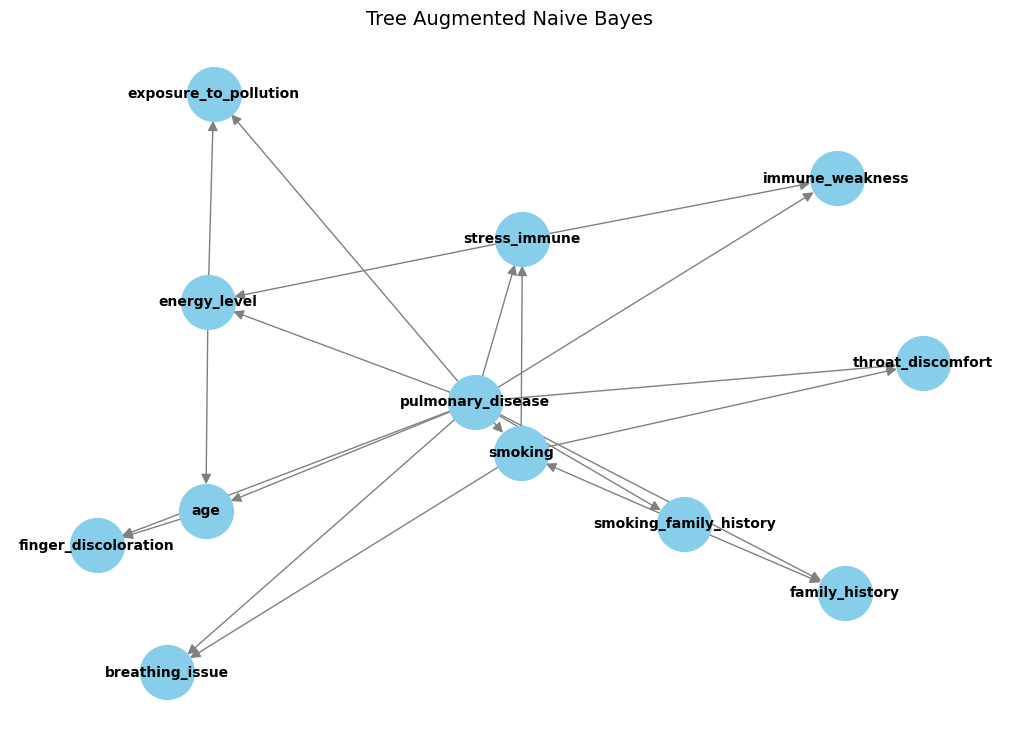

In [50]:
plot_pgmpy_model(model, title="Tree Augmented Naive Bayes")

### Bayesian Network

In [21]:
model, X_test_disc = train_bayesian_network(
    train_data_fs,
    test_data_fs,
    "pulmonary_disease",
    ['age', 'energy_level'],
    n_bins=5,
    discretization_method='quantile',
    structure_method = 'hillclimb_k2'
)

  0%|          | 15/100000 [00:00<31:24, 53.04it/s] 


In [16]:
# Get predictions
results = predict_bayesian_network(model, X_test_disc, target_col='pulmonary_disease')

y_pred = results['predictions']
y_proba = results['probabilities']

100%|██████████| 276/276 [00:07<00:00, 36.55it/s]


In [17]:
custom_reports_from_proba(y_test, y_proba)

* Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       444
           1       0.82      0.86      0.84       306

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.87      0.86      0.86       750

* Confusion Matrix:
[[386  58]
 [ 44 262]]

AUROC: 0.9195
Accuracy: 0.8640
Recall: 0.8562
Precision: 0.8187
F1 Score: 0.8371


,accuracy,roc_auc,precision,recall,f1_score
0,0.864,0.919545,0.81875,0.856209,0.837061


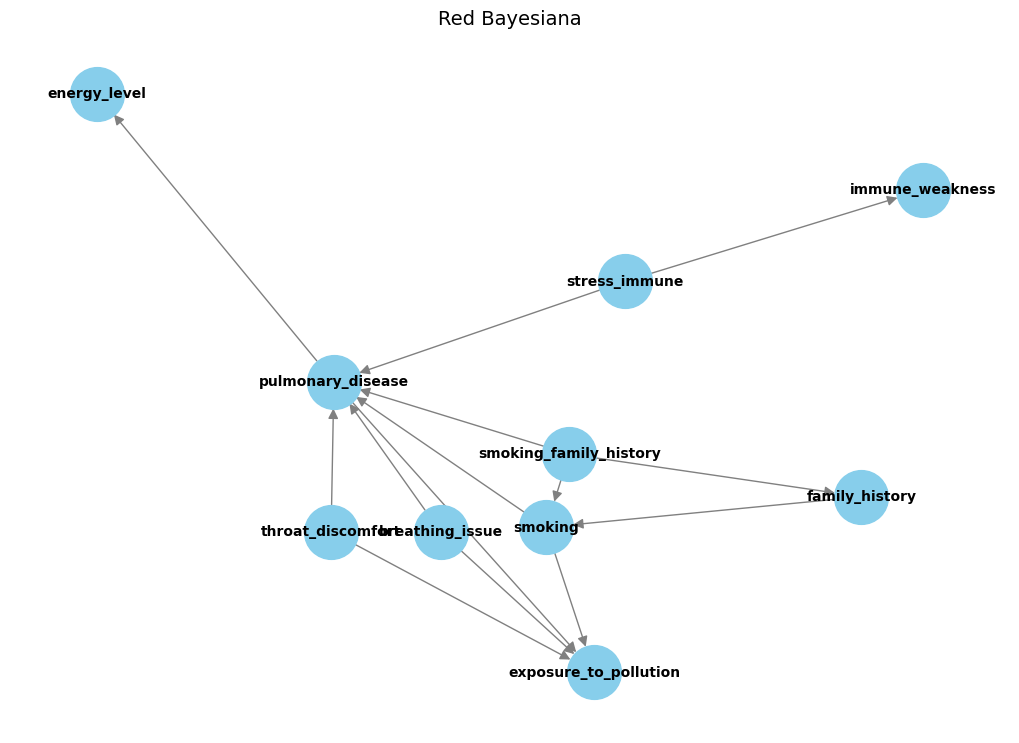

In [48]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_pgmpy_model(model, title="Bayesian Network Structure", seed = None):
    """
    Plot a pgmpy Bayesian or TAN model using networkx.
    """
    plt.figure(figsize=(10, 7))
    G = nx.DiGraph()
    G.add_edges_from(model.edges())
    
    pos = nx.spring_layout(G, seed=seed)  # consistent layout
    
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="skyblue",
        node_size=1500,
        font_size=10,
        font_weight="bold",
        arrowsize=15,
        edge_color="gray"
    )
    
    plt.title(title, fontsize=14)
    plt.show()

plot_pgmpy_model(model, title="Red Bayesiana")